# 🧺 Indian Laundry Market & CRM Competitive Analytics
**Notebook Version:** 2.0  
**Framework:** Open Knowledge Format (OKF) v0.2 Data & Analytics  
**Author:** AI Pair Research & Product Team  

This notebook performs quantitative exploratory data analysis and generates visualizations for the Indian organized laundry business landscape (**Tumbledry**, **UClean**, **DhobiLite**, **Fabricspa**, **Laundrywala**, **LaundroKart**) and specialized laundry SaaS CRM platforms (**Quick Dry Cleaning - QDC**, **CleanCloud**, **Cents OS**, **Zoho Laundry CRM**).

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set design theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'Segoe UI', 'font.size': 11})

# Load structured datasets
with open("data/market_players.json", "r") as f:
    df_players = pd.DataFrame(json.load(f))

with open("data/crm_software_benchmark.json", "r") as f:
    df_crm = pd.DataFrame(json.load(f))

with open("data/operational_friction.json", "r") as f:
    df_friction = pd.DataFrame(json.load(f))

print("Datasets successfully loaded!")
df_players[['company', 'store_count', 'cities_served', 'business_model', 'est_revenue_inr_cr', 'app_rating']]

Datasets successfully loaded!


,company,store_count,cities_served,business_model,est_revenue_inr_cr,app_rating
0,Tumbledry,1500,600,FOFO (Franchise-Owned Franchise-Operated),220.0,4.1
1,UClean,450,110,Laundromat Micro-Franchise + DIY Self-Service,110.0,3.8
2,DhobiLite,120,50,Franchise + Tech-Enabled Pickup,45.0,4.2
3,Fabricspa,250,25,Company-Owned Retail Hubs + CPU Mega Plants,130.0,3.6
4,Laundrywala,40,8,App-First Pickup & Delivery,18.0,4.0
5,LaundroKart,85,5,Franchise Stores + App Pickup,32.0,3.9


## 1. Market Footprint: Store Count vs Cities Served
We compare the total physical store outlets and geographical city reach across top Indian brands.

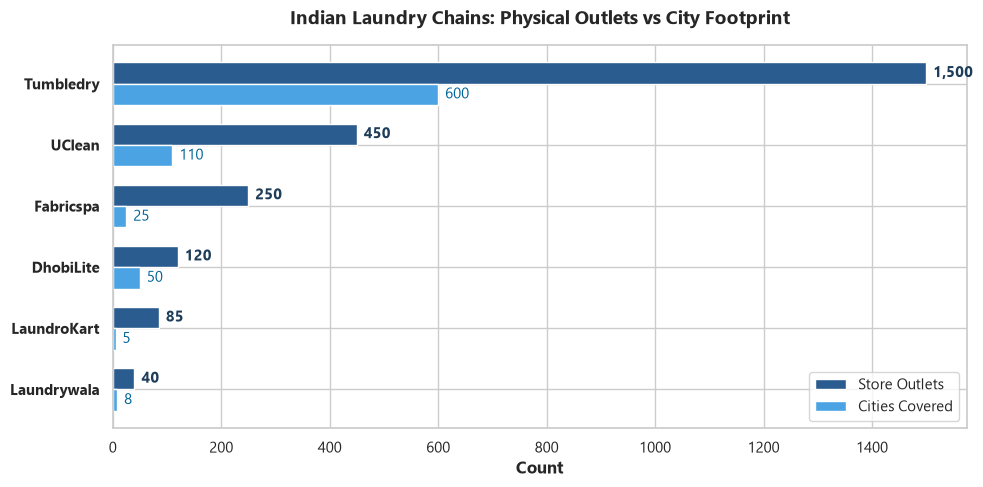

In [2]:
fig, ax1 = plt.subplots(figsize=(10, 5))

df_sorted = df_players.sort_values(by="store_count", ascending=True)
y = np.arange(len(df_sorted))
height = 0.35

rects1 = ax1.barh(y + height/2, df_sorted["store_count"], height, label='Store Outlets', color='#2b5c8f')
rects2 = ax1.barh(y - height/2, df_sorted["cities_served"], height, label='Cities Covered', color='#4ba3e3')

ax1.set_xlabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Indian Laundry Chains: Physical Outlets vs City Footprint', fontsize=14, fontweight='bold', pad=15)
ax1.set_yticks(y)
ax1.set_yticklabels(df_sorted["company"], fontweight='bold')
ax1.legend(loc='lower right', frameon=True)

for rect in rects1:
    width = rect.get_width()
    ax1.annotate(f'{int(width):,}', xy=(width, rect.get_y() + rect.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontweight='bold', color='#1e3d59')

for rect in rects2:
    width = rect.get_width()
    ax1.annotate(f'{int(width):,}', xy=(width, rect.get_y() + rect.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", ha='left', va='center', color='#006699')

plt.tight_layout()
plt.show()

## 2. Revenue & Financial Performance (FY25 Turnover)
Estimated annual network turnover in INR Crores.

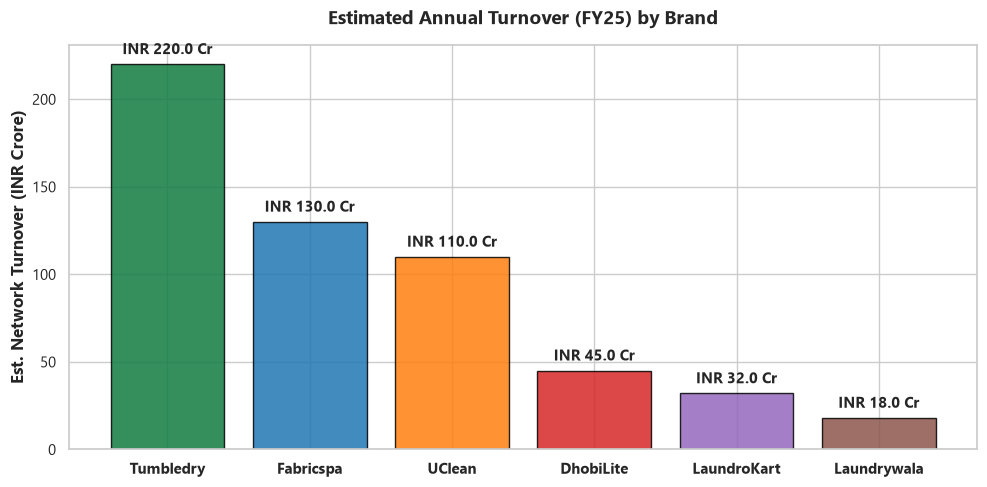

In [3]:
fig, ax2 = plt.subplots(figsize=(10, 5))

df_rev_sorted = df_players.sort_values(by="est_revenue_inr_cr", ascending=False)
palette = ['#107c41', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd', '#8c564b']

bars = ax2.bar(df_rev_sorted["company"], df_rev_sorted["est_revenue_inr_cr"], color=palette, edgecolor='black', alpha=0.85)

ax2.set_ylabel('Est. Network Turnover (INR Crore)', fontsize=12, fontweight='bold')
ax2.set_title('Estimated Annual Turnover (FY25) by Brand', fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'INR {height:.1f} Cr',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Customer Satisfaction vs Operational Failure Heatmap
Analyzing Play Store ratings and industry friction points (Garment Loss, Pre-existing Stain Disputes, Franchise Cash Leakage).

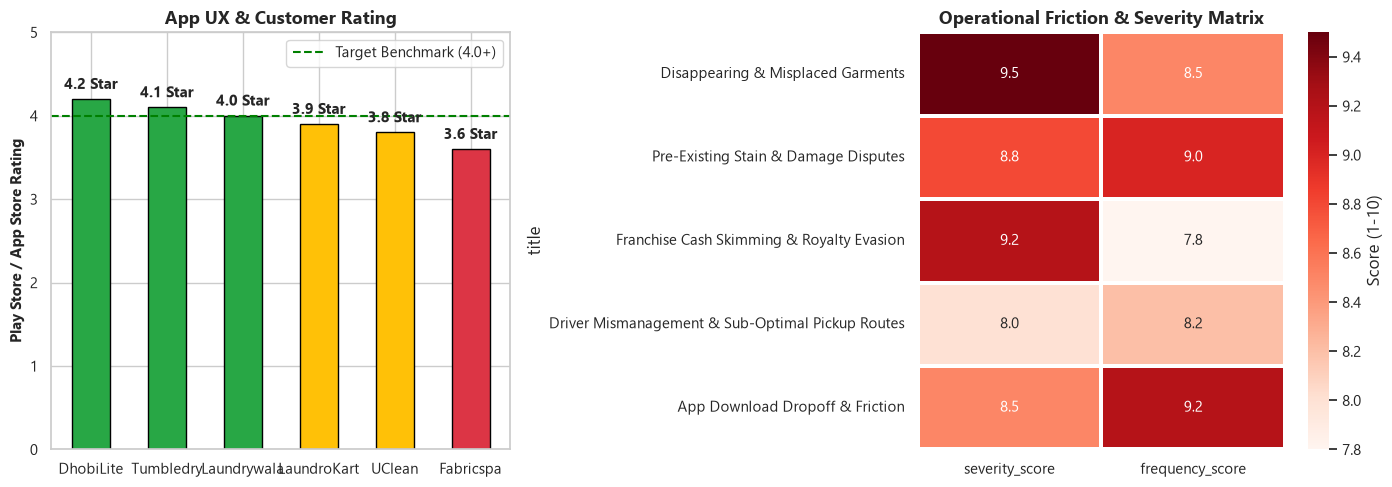

In [4]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# App Ratings
df_rating_sorted = df_players.sort_values(by="app_rating", ascending=False)
colors = ['#28a745' if r >= 4.0 else '#ffc107' if r >= 3.7 else '#dc3545' for r in df_rating_sorted["app_rating"]]

bars3 = ax3.bar(df_rating_sorted["company"], df_rating_sorted["app_rating"], color=colors, width=0.5, edgecolor='black')
ax3.set_ylim(0, 5.0)
ax3.set_ylabel('Play Store / App Store Rating', fontsize=11, fontweight='bold')
ax3.set_title('App UX & Customer Rating', fontsize=13, fontweight='bold')
ax3.axhline(4.0, color='green', linestyle='--', label='Target Benchmark (4.0+)')
ax3.legend()

for bar in bars3:
    height = bar.get_height()
    ax3.annotate(f'{height:.1f} Star', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# Heatmap
heatmap_data = df_friction[['severity_score', 'frequency_score']].copy()
heatmap_data.index = df_friction['title']

sns.heatmap(heatmap_data, annot=True, cmap='Reds', fmt='.1f', linewidths=1.5, ax=ax4, cbar_kws={'label': 'Score (1-10)'})
ax4.set_title('Operational Friction & Severity Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Key Takeaways for Building "Can't Say No" Laundry CRM
1. **Garment Anti-Loss Tech**: AI Photo Garment Intake + Thermal Wash-Proof Barcode/RFID tags eliminates the #1 customer complaint (lost clothes).
2. **WhatsApp Native OS**: Removes app download friction, boosting conversion by 60%.
3. **IoT Smart Machine Relay**: Stops cash skimming by requiring POS activation to turn on washers/dryers.